# Buổi 5 — Biến đổi và điều chỉnh dữ liệu

**Một câu:** trước khi dự báo, bỏ đi những thay đổi đã biết nguyên nhân (số ngày, lạm phát, dân số), làm dao động đều lại bằng
biến đổi, rồi nhớ rằng đổi ngược ra **trung vị**, không phải trung bình.

Tình huống: doanh số bán lẻ Mỹ năm 2025 gấp hơn 4 lần năm 1993, tháng 3 luôn cao hơn tháng 2, và năm doanh số cao thì chênh
giữa tháng đông và tháng vắng cũng lớn. Phần nào là nhu cầu thật? Sáu phần dưới bóc từng lớp.

| Phần | Câu hỏi |
|---|---|
| 1 | Tháng 3 cao hơn tháng 2 vì mua nhiều hơn hay vì dài hơn? |
| 2 | "Gấp 4 lần" còn bao nhiêu khi trừ lạm phát và dân số? |
| 3 | Vì sao log làm dao động đều lại? |
| 4 | Log ép quá tay thì chọn nấc nào? |
| 5 | Đổi ngược từ thang log ra con số gì? |
| 6 | Trên dữ liệu thật, hiệu chỉnh bias đáng bao nhiêu? |

## 0. Dữ liệu

**Bộ dữ liệu Monthly Retail Trade Survey (MARTS).** Cục Điều tra Dân số Mỹ (Census Bureau) khảo sát doanh số **bán lẻ và dịch vụ ăn uống** mỗi tháng, từ 1/1992 tới
nay, cho tổng toàn nước Mỹ và từng ngành (trạm xăng, bách hoá, nhà sách…), đơn vị **triệu USD**. Tệp Excel có một sheet mỗi
năm; mỗi sheet có hai khối: **NOT ADJUSTED** (số thật, chưa bỏ mùa vụ — số ta dùng) và **ADJUSTED** (đã bỏ mùa vụ, ngày lễ và
chênh lệch số ngày bán hàng). Ô không công bố ghi `(S)` hoặc `(NA)`.

Nguồn: Source: U.S. Census Bureau, Monthly Retail Trade Survey (bản lưu Internet Archive 2026-09-13). Giấy phép Public domain (U.S. government, 17 U.S.C. §105).

| Cột | Nghĩa |
|---|---|
| `cột B` | tên chuỗi, ví dụ `Retail and food services sales, total`, `Gasoline stations` |
| `Jan. 2025 … Dec. 2025` | doanh số của tháng đó (triệu USD); mỗi sheet 12 cột tháng |

**Bộ dữ liệu Consumer Price Index for All Urban Consumers (CPI-U).** Cục Thống kê Lao động Mỹ (BLS) theo dõi giá một giỏ hàng tiêu dùng mỗi tháng, từ 1913, quy về **1982–1984 = 100**.
Tệp là bảng dài phân cách bằng tab: mỗi dòng là một tháng của một chuỗi CPI. Chuỗi `CUUR0000SA0` là CPI mọi mặt hàng,
**chưa** điều chỉnh mùa vụ. Tháng 10/2025 BLS không công bố (ghi `-`).

Nguồn: U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers (truy cập 2026-09-17). Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `series_id` | mã chuỗi (có khoảng trắng thừa ở cuối); `CUUR0000SA0` = CPI mọi mặt hàng, chưa điều chỉnh mùa vụ |
| `year`, `period` | năm và tháng `M01`…`M12`; `M13` là trung bình năm — bỏ đi |
| `value` | giá trị chỉ số (1982–1984 = 100) |

**Bộ dữ liệu BEA National Income and Product Accounts — monthly.** Cục Phân tích Kinh tế Mỹ (BEA) công bố hệ thống tài khoản quốc gia; tệp này gom **mọi chuỗi theo tháng** vào một
bảng dài ba cột (khoảng 37 MB). Mỗi dòng là một tháng của một chuỗi. Chuỗi `B230RC` là **dân số giữa kỳ** của Mỹ, nghìn
người; `B230RC` tăng đều, không có mùa vụ.

Nguồn: Source: U.S. Bureau of Economic Analysis, National Income and Product Accounts (truy cập 2026-09-17). Giấy phép Public domain (U.S. government).

| Cột | Nghĩa |
|---|---|
| `%SeriesCode` | mã chuỗi, ví dụ `B230RC` (dân số) |
| `Period` | tháng, dạng `2024M03` |
| `Value` | giá trị, có dấu phẩy ngăn nghìn |

Ô dưới tải dữ liệu (40 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [3]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "census-marts-ban-le": ("2c58dce5119a7ff2acf08643a34f514d7b130b531fa989849470a7eeb075abee", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/census-marts-ban-le/mrtssales92-present.xlsx",
        "https://web.archive.org/web/20260913170508id_/https://www.census.gov/retail/mrts/www/mrtssales92-present.xlsx",
    ]),
    "bls-cpi-u": ("47507ab13d9366d6e9f6a85a50bbd863179c97fa51c92ecb737875455d6ddc0f", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/bls-cpi-u/cu.data.1.AllItems.tsv",
        "https://download.bls.gov/pub/time.series/cu/cu.data.1.AllItems",
    ]),
    "bea-nipa-thang": ("dd14f325cc4b73c697d6f1de0eeeb5bc8a4c5f4f6ce61482d4225c14c4d371f3", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/bea-nipa-thang/NipaDataM.txt",
        "https://apps.bea.gov/national/Release/TXT/NipaDataM.txt",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

census-marts-ban-le          /home/tony/.cache/khoa-forecasting/sha256/2c/2c58dce5119a7ff2acf08643a34f514d7b130b531fa989849470a7eeb075abee
bls-cpi-u                    /home/tony/.cache/khoa-forecasting/sha256/47/47507ab13d9366d6e9f6a85a50bbd863179c97fa51c92ecb737875455d6ddc0f
bea-nipa-thang               /home/tony/.cache/khoa-forecasting/sha256/dd/dd14f325cc4b73c697d6f1de0eeeb5bc8a4c5f4f6ce61482d4225c14c4d371f3


In [4]:
import re

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
from scipy import stats

TONG = "Retail and food services sales, total"


def doc_marts():
    # mỗi sheet một năm; dòng 5 là nhãn tháng ("Jan. 2025", "May 2025"); cột B là tên chuỗi; hai khối NOT ADJUSTED / ADJUSTED(2)
    bang = {}
    tep = open(lay("census-marts-ban-le"), "rb")                      # tệp cache không có đuôi .xlsx → đưa openpyxl tệp đã mở
    wb = openpyxl.load_workbook(tep, read_only=True, data_only=True)
    for sheet in wb.sheetnames:
        dong = list(wb[sheet].iter_rows(values_only=True))
        cot = {}
        for j, nhan in enumerate(dong[4]):
            m = re.match(r"^([A-Z][a-z]{2})\.? (\d{4})", nhan) if isinstance(nhan, str) else None
            if m:
                cot[j] = pd.Timestamp(f"{m.group(2)}-{pd.to_datetime(m.group(1), format='%b').month:02d}-01")
        khoi = None
        for r in dong[5:]:
            if r[1] in ("NOT ADJUSTED", "ADJUSTED(2)"):
                khoi = r[1]
            elif khoi and isinstance(r[1], str):
                gia_tri = bang.setdefault((khoi, r[1].strip()), {})
                for j, thang in cot.items():
                    gia_tri[thang] = pd.to_numeric(r[j], errors="coerce")      # "(S)", "(NA)" → NaN
    wb.close()
    tep.close()
    return {k: pd.Series(v).sort_index().asfreq("MS") for k, v in bang.items()}


MARTS = doc_marts()


def ban_le(ten=TONG, da_dieu_chinh=False):
    return MARTS[("ADJUSTED(2)" if da_dieu_chinh else "NOT ADJUSTED", ten)]


cu = pd.read_csv(lay("bls-cpi-u"), sep="\t", dtype=str)
cu.columns = cu.columns.str.strip()
cu = cu[(cu["series_id"].str.strip() == "CUUR0000SA0") & (cu["period"] != "M13")]
cpi = pd.Series(pd.to_numeric(cu["value"].str.strip(), errors="coerce").to_numpy(),        # "-" (10/2025) → NaN
                index=pd.to_datetime(cu["year"].str.strip() + "-" + cu["period"].str[1:] + "-01")).sort_index().asfreq("MS")
nipa = pd.read_csv(lay("bea-nipa-thang"), thousands=",")
nipa = nipa[nipa["%SeriesCode"] == "B230RC"]
dan_so = pd.Series(nipa["Value"].astype(float).to_numpy(),                                   # nghìn người
                   index=pd.to_datetime(nipa["Period"].str.replace("M", "-") + "-01")).sort_index().asfreq("MS")

y = ban_le()
print(f"bán lẻ {y.index[0]:%m/%Y} → {y.index[-1]:%m/%Y}, {len(y)} tháng, thiếu {y.isna().sum()}")
print(f"CPI tháng thiếu từ 1990: {[f'{t:%m/%Y}' for t in cpi['1990':].index[cpi['1990':].isna()]]}")

bán lẻ 01/1992 → 06/2026, 414 tháng, thiếu 0
CPI tháng thiếu từ 1990: ['10/2025']


## 1. Chia số ngày có thể đảo dấu kết luận

**Vấn đề.** Tháng 3 thường bán nhiều hơn tháng 2. Một phần vì người ta mua nhiều hơn, một phần chỉ vì tháng 3 dài hơn 3 ngày.

> **điều chỉnh lịch** · *calendar adjustment*
>
> - **Là gì:** chia tổng tháng cho số ngày (hoặc số ngày bán hàng) để tháng dài và tháng ngắn so được với nhau.
> - **Ví dụ:** tháng 2 bán 280 tỷ trong 28 ngày, tháng 3 bán 310 tỷ trong 31 ngày: so thẳng +10,7%, chia ngày thì cả hai 10 tỷ/ngày — không đổi.
> - **Để làm gì:** bỏ phần thay đổi chỉ do lịch, để mô hình học nhu cầu thật.

**Lý do.** Doanh số mỗi ngày = tổng tháng / số ngày của tháng. Mức tinh hơn: chia cho số ngày **bán hàng** (ví dụ số ngày không
phải Chủ nhật). Census còn công bố chuỗi đã điều chỉnh (ADJUSTED), bỏ cả mùa vụ, ngày lễ và chênh lệch ngày bán hàng.

**Kết quả.** Ba tháng đầu năm 2023:

In [5]:
ba = y["2023-01":"2023-03"]
khong_cn = [sum(d.dayofweek != 6 for d in pd.date_range(t, t + pd.offsets.MonthEnd(0))) for t in ba.index]
bang = pd.DataFrame({"tổng": ba, "số ngày": ba.index.days_in_month, "mỗi ngày": ba / ba.index.days_in_month,
                     "ngày không CN": khong_cn, "mỗi ngày không CN": ba / khong_cn}).set_axis(["T1", "T2", "T3"])
print(bang.round(0).astype(int))
adj = ban_le(da_dieu_chinh=True)
for truoc, sau in [("T1", "T2"), ("T2", "T3")]:
    so = (bang.loc[sau] / bang.loc[truoc] - 1) * 100
    t0, t1 = pd.Timestamp(f"2023-{truoc[1:]}-01"), pd.Timestamp(f"2023-{sau[1:]}-01")
    print(f"{sau}/{truoc}: thẳng {so['tổng']:+.2f}% | chia ngày lịch {so['mỗi ngày']:+.2f}% | "
          f"chia ngày không CN {so['mỗi ngày không CN']:+.2f}% | ADJUSTED {(adj[t1] / adj[t0] - 1) * 100:+.2f}%")

      tổng  số ngày  mỗi ngày  ngày không CN  mỗi ngày không CN
T1  616100       31     19874             26              23696
T2  595432       28     21265             24              24810
T3  679701       31     21926             27              25174
T2/T1: thẳng -3.35% | chia ngày lịch +7.00% | chia ngày không CN +4.70% | ADJUSTED -1.19%
T3/T2: thẳng +14.15% | chia ngày lịch +3.11% | chia ngày không CN +1.47% | ADJUSTED -1.05%


Tháng 2 **giảm** 3,4% theo tổng nhưng **tăng** 7,0% theo ngày: dấu kết luận đảo ngược. Tháng 3 so tháng 2 co dần từ
+14,15% (thẳng) xuống +3,11%, +1,47% rồi −1,05% (ADJUSTED) — mỗi cột bỏ thêm một nguyên nhân đã biết.

**Bài học.** Chia số ngày trước khi so hai tháng, và nói rõ đã bỏ gì: ngày lịch, ngày bán hàng, hay dùng chuỗi đã điều chỉnh.
Không con số nào sai; mỗi con số trả lời một câu hỏi khác.

## 2. "Gấp 4 lần" chỉ còn +42% khi trừ lạm phát và chia dân số

**Vấn đề.** Doanh số bán lẻ Mỹ năm 2025 gấp hơn 4 lần năm 1993. Nhưng giá cả tăng, dân số cũng đông hơn. Mỗi người thật sự mua
nhiều hơn bao nhiêu?

> **giá danh nghĩa / giá thực** · *nominal / real value*
>
> - **Là gì:** danh nghĩa là số tiền ghi lúc đó; thực là số đó đổi về sức mua của một năm gốc.
> - **Ví dụ:** doanh thu 150 tỷ lúc giá chung gấp 1,25 lần năm gốc = 150 / 1,25 = 120 tỷ theo giá năm gốc.
> - **Để làm gì:** tách phần tăng do bán nhiều hơn khỏi phần tăng chỉ do giá cao hơn.

> **CPI** · *Consumer Price Index*
>
> - **Là gì:** chỉ số giá tiêu dùng — con số theo dõi giá một giỏ hàng cố định; tăng 10% nghĩa là giá chung tăng 10%.
> - **Ví dụ:** CPI 100 → 125: giá chung tăng 25%.
> - **Để làm gì:** là thước để đổi danh nghĩa ra thực.

> **năm gốc** · *base year*
>
> - **Là gì:** năm mà ta đổi mọi con số về sức mua của nó.
> - **Ví dụ:** "USD năm 2025": mọi năm đều quy về giá của năm 2025.
> - **Để làm gì:** chọn năm gốc gần hiện tại để con số dễ hình dung.

> **trên đầu người** · *per capita*
>
> - **Là gì:** chia cho dân số.
> - **Ví dụ:** 120 tỷ / 12 triệu người = 10 nghìn mỗi người.
> - **Để làm gì:** tách phần tăng do mỗi người mua nhiều hơn khỏi phần tăng do thêm người.

**Lý do.** Giá thực = danh nghĩa / CPI lúc đó × CPI năm gốc:

$$x_t = \frac{y_t}{z_t} \times z_{\text{gốc}}$$

Ví dụ tay: doanh thu 100 → 150, CPI 100 → 125, dân số 10 → 12 triệu. Giá thực năm sau 150 / 125 × 100 = 120 (tăng 20%, không phải
50%); chia dân số: 100 / 10 = 120 / 12 = 10 — mỗi người mua y như cũ.

**Kết quả.** Năm gốc 2025; tháng 10/2025 CPI không công bố nên nội suy một tháng:

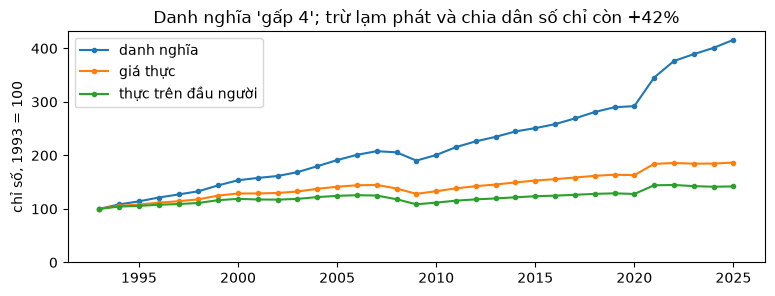

chỉ số 2025: {'danh nghĩa': 416, 'giá thực': 187, 'thực trên đầu người': 142}
CPI TB năm: 1993 = 144.5, 2025 = 321.94 | dân số (triệu): 1993 = 260.3, 2025 = 341.9


In [6]:
cpi_du = cpi.interpolate(limit=1, limit_area="inside")
thuc = y / cpi_du.reindex(y.index) * cpi_du["2025"].mean()
dau_nguoi = thuc / dan_so.reindex(y.index) * 1e6               # dân số tính bằng nghìn người
nam = pd.DataFrame({"danh nghĩa": y, "giá thực": thuc, "thực trên đầu người": dau_nguoi}).resample("YS").sum()["1993":"2025"]
chi_so = nam / nam.iloc[0] * 100                                # đánh chỉ số: 1993 = 100
ax = chi_so.set_index(chi_so.index.year).plot(figsize=(9, 3), marker="o", ms=3,
                                              title="Danh nghĩa 'gấp 4'; trừ lạm phát và chia dân số chỉ còn +42%")
ax.set(ylim=(0, None), ylabel="chỉ số, 1993 = 100", xlabel="")
plt.show()
print("chỉ số 2025:", chi_so.iloc[-1].round(0).astype(int).to_dict())
print(f"CPI TB năm: 1993 = {cpi['1993'].mean():.1f}, 2025 = {cpi['2025'].mean():.2f} | "
      f"dân số (triệu): 1993 = {dan_so['1993'].mean() / 1000:.1f}, 2025 = {dan_so['2025'].mean() / 1000:.1f}")

Chỉ số năm 2025 đi 416 → 187 → 142. Giá chung tăng 321,94 / 144,5 = 2,23 lần, dân số 1,31 lần — hai thứ đó giải thích gần hết
"gấp 4". Phần còn lại, +42% trong 32 năm, là khoảng 1,1% mỗi năm.

**Bài học.** "Tăng bao nhiêu" phải nói rõ là danh nghĩa, thực, hay thực trên đầu người. Dự báo doanh thu thường dự báo **giá
thực** rồi nhân lại CPI dự báo.

## 3. Log: cùng phần trăm thì cùng khoảng cách

**Vấn đề.** Năm doanh số cao thì chênh giữa tháng đông và tháng vắng cũng lớn. Nhiều mô hình (phân rã, ETS, ARIMA ở các buổi
sau) giả định dao động to như nhau ở mọi mức.

> **log, exp** · *natural logarithm, exponential*
>
> - **Là gì:** $\log y$ trả lời "$e$ mũ mấy thì bằng $y$" (log tự nhiên, $e \approx 2{,}718$); `exp` làm ngược lại. Vì $\log(a \times b) = \log a + \log b$, log biến phép **nhân** thành phép **cộng**.
> - **Ví dụ:** $\log 100 = 4{,}605$, $\log 120 = 4{,}787$: tăng 20% thành cộng 0,182 — ở mức 1.000 → 1.200 cũng đúng 0,182.
> - **Để làm gì:** làm dao động đều lại khi dao động lớn lên tỷ lệ với mức; chỉ dùng cho số dương.
>
> 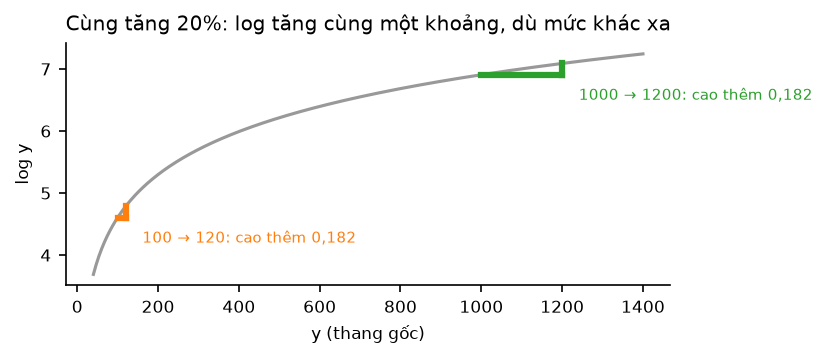

**Lý do.** Cửa hàng nhỏ tăng 20% (100 → 120, chênh 20) và siêu thị tăng 20% (1.000 → 1.200, chênh 200) khác nhau trên thang
gốc nhưng **giống nhau** trên thang log. Nếu dao động tỷ lệ với mức, log làm chúng đều lại.

**Kết quả.** Mỗi năm 1992–2019 một chấm: mức trung bình tháng và độ lệch chuẩn của 12 tháng trong năm.

log: [4.605 4.787 6.908 7.09 ] | log 1,2 = 0.182


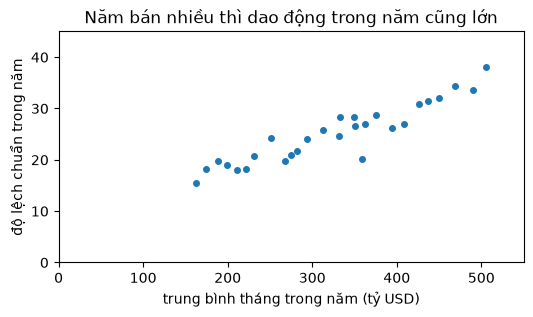

1992 → 2019: mức 162.9 → 505.4 (gấp 3.1); dao động 15.6 → 38.1 (gấp 2.4)


In [7]:
print("log:", np.log([100, 120, 1000, 1200]).round(3), "| log 1,2 =", round(np.log(1.2), 3))

y19 = y[:"2019-12"]
khoi = y19.to_numpy()[y19.size % 12:].reshape(-1, 12) / 1000          # 28 năm × 12 tháng, tỷ USD
tb, sd = khoi.mean(axis=1), khoi.std(axis=1, ddof=1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(tb, sd, "o", ms=4)
ax.set(xlim=(0, 550), ylim=(0, 45), xlabel="trung bình tháng trong năm (tỷ USD)", ylabel="độ lệch chuẩn trong năm",
       title="Năm bán nhiều thì dao động trong năm cũng lớn")
plt.show()
print(f"1992 → 2019: mức {tb[0]:.1f} → {tb[-1]:.1f} (gấp {tb[-1] / tb[0]:.1f}); dao động {sd[0]:.1f} → {sd[-1]:.1f} (gấp {sd[-1] / sd[0]:.1f})")

Mức gấp 3,1 lần, dao động gấp 2,4 lần: dao động lớn lên theo mức, nhưng **chậm hơn** mức. Log hợp nhất khi dao động gấp
đúng bằng mức; ở đây log sẽ ép quá tay.

**Bài học.** Log biến tăng theo phần trăm thành tăng theo khoảng cách. Trước khi lấy log, kiểm dao động lớn lên nhanh cỡ nào so
với mức.

## 4. Guerrero chọn λ ≈ 0,34 cho bán lẻ Mỹ, không phải log

**Vấn đề.** Không biến đổi thì dao động phình ra theo mức; log thì ép quá tay. Cần một nấc ở giữa, chọn bằng số.

> **biến đổi Box-Cox** · *Box-Cox transformation*
>
> - **Là gì:** họ phép biến đổi chọn bằng một số $\lambda$: $w = (y^\lambda - 1)/\lambda$, riêng $\lambda = 0$ là $\log y$. $\lambda = 1$ gần như giữ nguyên, $\lambda = 0$ là log, ở giữa thì ép vừa.
> - **Ví dụ:** $y$ = 100: $\lambda$ = 1 cho 99; $\lambda$ = 0,5 cho (10 − 1) / 0,5 = 18; $\lambda$ = 0 cho 4,605.
> - **Để làm gì:** có một nấc ép vừa đủ cho dữ liệu mà log ép quá tay.
>
> 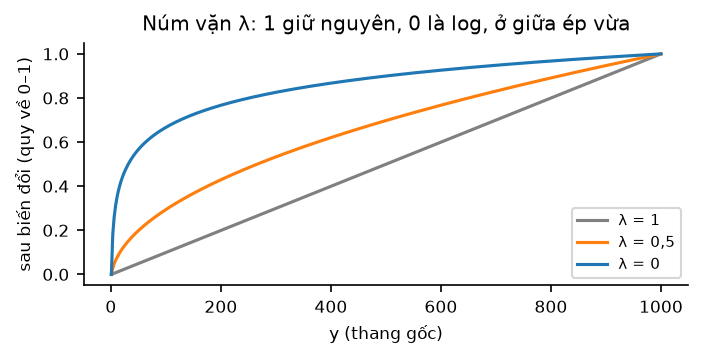

> **hệ số biến thiên (CV)** · *coefficient of variation*
>
> - **Là gì:** độ lệch chuẩn chia trung bình: dao động to cỡ bao nhiêu phần của mức.
> - **Ví dụ:** ba số 10, 20, 30: độ lệch chuẩn 10, trung bình 20 → CV = 0,5. Ba số bằng nhau → CV = 0.
> - **Để làm gì:** đo "đều tới đâu" bằng một con số, bất kể đơn vị.

> **Guerrero** · *Guerrero's method*
>
> - **Là gì:** cách chọn $\lambda$: chia chuỗi thành từng năm, tính tỷ số $s / \mu^{1-\lambda}$ (độ lệch chuẩn chia mức mũ $1 - \lambda$) mỗi năm, chọn $\lambda$ làm CV của các tỷ số nhỏ nhất.
> - **Ví dụ:** ba năm $\mu$ = 100, 400, 900, $s$ = 10, 20, 30: với $\lambda$ = 0,5 tỷ số là 1, 1, 1 — đều hoàn toàn.
> - **Để làm gì:** chọn $\lambda$ bằng số, không bằng mắt, sao cho dao động mỗi năm đều nhau sau biến đổi.

> **Yeo-Johnson** · *Yeo-Johnson transformation*
>
> - **Là gì:** biến thể của Box-Cox nhận được cả số 0 và số âm.
> - **Ví dụ:** chuỗi phần trăm tăng trưởng có 25 tháng âm: Box-Cox báo lỗi, Yeo-Johnson chạy được.
> - **Để làm gì:** biến đổi chuỗi có giá trị âm (tăng trưởng, lợi nhuận).

**Lý do.** Sau Box-Cox, độ lệch chuẩn của một năm có mức $\mu$ xấp xỉ $s / \mu^{1-\lambda}$ — với log ($\lambda = 0$) là $s / \mu$:
dao động bị chia cho mức. Tìm $\lambda$ để tỷ số đó **như nhau ở mọi năm**, đo bằng CV nhỏ nhất.

**Kết quả.** Ví dụ ba năm tính tay, rồi dữ liệu thật:

In [8]:
def boxcox(y, lam):
    y = np.asarray(y, dtype=float)
    return np.log(y) if lam == 0 else (np.sign(y) * np.abs(y) ** lam - 1) / lam


def guerrero(y, m):
    luoi = np.linspace(-1, 2, 3001)                               # thử λ từ −1 tới 2, bước 0,001
    y = np.asarray(y, dtype=float)
    khoi = y[y.size % m:].reshape(-1, m)                          # bỏ khối đầu thiếu
    tb, sd = khoi.mean(axis=1), khoi.std(axis=1, ddof=1)
    ty_so = sd[None, :] / tb[None, :] ** (1 - luoi[:, None])
    cv = ty_so.std(axis=1, ddof=1) / ty_so.mean(axis=1)
    return float(luoi[np.argmin(cv)])


mu, s = np.array([100, 400, 900]), np.array([10, 20, 30])
for lam in (1, 0.5, 0):
    ty_so = s / mu ** (1 - lam)
    print(f"ví dụ tay λ = {lam}: tỷ số {ty_so.round(3)}, CV {ty_so.std(ddof=1) / ty_so.mean():.3f}")

lam_g = guerrero(y19, 12)
lam_mle = stats.boxcox(y19.to_numpy())[1]
print(f"\nbán lẻ 1992–2019: λ Guerrero = {lam_g:.3f} | scipy (MLE) = {lam_mle:.3f}")
for lam in (1.0, lam_g, 0.0):
    kh = boxcox(khoi * 1000, lam).std(axis=1, ddof=1)
    print(f"  λ = {lam:.2f}: dao động năm 2019 / năm 1992 = {kh[-1] / kh[0]:.2f}")

ví dụ tay λ = 1: tỷ số [10. 20. 30.], CV 0.500
ví dụ tay λ = 0.5: tỷ số [1. 1. 1.], CV 0.000
ví dụ tay λ = 0: tỷ số [0.1   0.05  0.033], CV 0.568

bán lẻ 1992–2019: λ Guerrero = 0.343 | scipy (MLE) = 0.595
  λ = 1.00: dao động năm 2019 / năm 1992 = 2.45
  λ = 0.34: dao động năm 2019 / năm 1992 = 1.21
  λ = 0.00: dao động năm 2019 / năm 1992 = 0.84


Không biến đổi, dao động 2019 gấp 2,45 lần 1992; log co lại còn 0,84 (ép quá tay); $\lambda$ Guerrero 0,34 cho 1,21, gần 1 nhất.
`scipy.stats.boxcox` chọn 0,595 theo tiêu chí khác (làm dữ liệu giống hình chuông nhất) — trả lời câu hỏi khác, không phải
"dao động đều". Kiểm lại bằng thư viện và thử với số âm:

In [9]:
from scipy.special import boxcox as boxcox_scipy
from statsmodels.base.transform import BoxCox

print("lệch tối đa so với scipy.special.boxcox:", np.abs(boxcox(y19, lam_g) - boxcox_scipy(y19.to_numpy(), lam_g)).max())
print("statsmodels Guerrero (window_length=12):", round(BoxCox().transform_boxcox(y19.to_numpy(), method="guerrero",
                                                                                 window_length=12)[1], 3))
tang = (y.pct_change(12) * 100).dropna()                       # % so với cùng tháng năm trước
try:
    stats.boxcox(tang.to_numpy())
except ValueError as loi:
    print(f"Box-Cox trên {(tang <= 0).sum()} tháng âm:", loi)
print("Yeo-Johnson λ =", round(stats.yeojohnson(tang.to_numpy())[1], 3))

lệch tối đa so với scipy.special.boxcox: 1.7053025658242404e-13
statsmodels Guerrero (window_length=12): 0.343
Box-Cox trên 25 tháng âm: Data must be positive.
Yeo-Johnson λ = 1.025


Yeo-Johnson chọn $\lambda$ ≈ 1,02: chuỗi tăng trưởng gần như không cần biến đổi. `window_length` của statsmodels mặc định là 4 —
quên truyền 12 thì ra $\lambda$ khác.

**Bài học.** $\lambda$ là **tham số của mô hình**: trong backtest, tính $\lambda$ chỉ từ dữ liệu trước gốc dự báo, lưu lại, và đổi
ngược bằng đúng $\lambda$ đó. Chọn $\lambda$ bằng cả chuỗi rồi backtest là dùng dữ liệu tương lai.

## 5. Đổi ngược thẳng cho trung vị, thấp hơn trung bình

**Vấn đề.** Dự báo trên thang log xong, lấy `exp` để về đơn vị gốc. Con số nhận được thường **thấp hơn** trung bình thật.

> **đổi ngược** · *back-transform*
>
> - **Là gì:** đưa dự báo trên thang đã biến đổi về thang gốc; với log là lấy `exp`.
> - **Ví dụ:** dự báo log 4,6 → $\exp(4{,}6) \approx 99{,}5$.
> - **Để làm gì:** dự báo phải báo cáo bằng đơn vị gốc (USD, lượt), không phải bằng log.
>
> 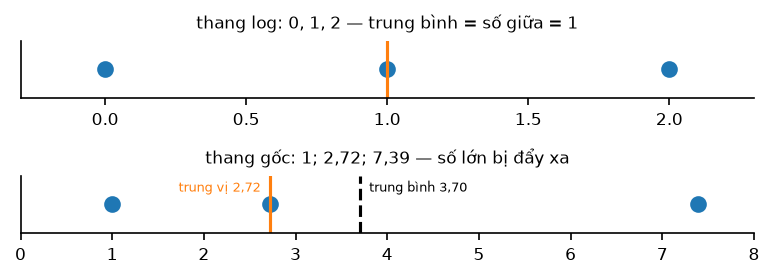

> **log-normal** · *log-normal distribution*
>
> - **Là gì:** số $y = \exp(w)$ với $w$ có phân phối chuẩn (hình chuông): luôn dương, lệch phải, trung bình lớn hơn trung vị.
> - **Ví dụ:** doanh số, giá nhà: đa số ở mức vừa, vài giá trị rất lớn.
> - **Để làm gì:** là hình dạng của dự báo sau khi đổi ngược từ thang log — nên trung vị và trung bình tách nhau.

> **hiệu chỉnh bias** · *bias adjustment*
>
> - **Là gì:** nhân dự báo đổi ngược với $1 + \sigma^2/2$ ($\sigma^2$ là phương sai của dự báo trên thang log) để ra trung bình thay vì trung vị.
> - **Ví dụ:** dự báo log 4,6, $\sigma^2$ = 0,04: 99,5 × (1 + 0,02) ≈ 101,5.
> - **Để làm gì:** cần khi cộng dồn dự báo nhiều tháng, nhiều cửa hàng: trung bình cộng được, trung vị thì không.

**Lý do.** `exp` giữ nguyên thứ tự, nên số đứng giữa trên thang log vẫn đứng giữa: đổi ngược thẳng ra **trung vị**. Nhưng
`exp` kéo giãn phía trên, đẩy trung bình lên trên trung vị. Công thức (FPP §5.6), với $\hat w$ là tâm và $\sigma^2$ là phương sai trên
thang log:

$$\text{trung vị} = e^{\hat w}, \qquad \text{trung bình} = e^{\hat w + \sigma^2/2} \approx e^{\hat w}\left(1 + \frac{\sigma^2}{2}\right)$$

**Kết quả.** Ví dụ tay 0, 1, 2 rồi mô phỏng 100.000 mẫu (seed 42):

exp(trung bình log) = 2.72 | trung bình thật = 3.70 | số giữa = 2.72


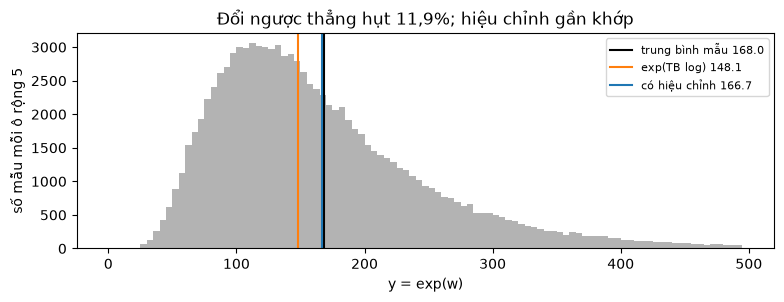

hụt: thẳng -11.9% | có hiệu chỉnh -0.75%
σ = 0.1: trung vị thấp hơn trung bình -0.50% | công thức FPP còn hụt -0.00%
σ = 0.3: trung vị thấp hơn trung bình -4.40% | công thức FPP còn hụt -0.10%
σ = 0.5: trung vị thấp hơn trung bình -11.75% | công thức FPP còn hụt -0.72%
σ = 1.0: trung vị thấp hơn trung bình -39.35% | công thức FPP còn hụt -9.02%


In [10]:
w = np.array([0.0, 1.0, 2.0])
print(f"exp(trung bình log) = {np.exp(w.mean()):.2f} | trung bình thật = {np.exp(w).mean():.2f} | số giữa = {np.median(np.exp(w)):.2f}")

x = np.random.default_rng(42).lognormal(5.0, 0.5, 100_000)
wx = np.log(x)
trung_vi, fpp = np.exp(wx.mean()), np.exp(wx.mean()) * (1 + wx.var(ddof=1) / 2)
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.hist(x, bins=np.arange(0, 500, 5), color="0.7")
for v, mau, ten in [(x.mean(), "k", "trung bình mẫu"), (trung_vi, "tab:orange", "exp(TB log)"), (fpp, "tab:blue", "có hiệu chỉnh")]:
    ax.axvline(v, color=mau, lw=1.5, label=f"{ten} {v:.1f}")
ax.set(xlabel="y = exp(w)", ylabel="số mẫu mỗi ô rộng 5", title="Đổi ngược thẳng hụt 11,9%; hiệu chỉnh gần khớp")
ax.legend(fontsize=8)
plt.show()
print(f"hụt: thẳng {(trung_vi / x.mean() - 1) * 100:.1f}% | có hiệu chỉnh {(fpp / x.mean() - 1) * 100:.2f}%")
for sig in (0.1, 0.3, 0.5, 1.0):
    print(f"σ = {sig}: trung vị thấp hơn trung bình {-(1 - np.exp(-sig**2 / 2)) * 100:.2f}% | "
          f"công thức FPP còn hụt {((1 + sig**2 / 2) / np.exp(sig**2 / 2) - 1) * 100:.2f}%")

$\sigma$ nhỏ thì gần như không hụt; $\sigma$ = 1 thì trung vị hụt gần 40%. Xấp xỉ $1 + \sigma^2/2$ tốt tới $\sigma$ khoảng 0,5; lớn
hơn thì dùng dạng chính xác $e^{\hat w + \sigma^2/2}$. Với $\lambda \ne 0$ công thức cùng ý:
$\hat y = (\lambda \hat w + 1)^{1/\lambda}\left[1 + \frac{\sigma^2 (1 - \lambda)}{2(\lambda \hat w + 1)^2}\right]$.

**Bài học.** Muốn trung bình thì nhân thêm $1 + \sigma^2/2$ — nhân, hoặc cộng $\sigma^2/2$ vào $\hat w$ **trước** khi lấy exp; không
cộng vào kết quả sau.

## 6. Trên bán lẻ thật, hiệu chỉnh đúng cỡ σ²/2 nhưng nhỏ hơn lỗi mô hình

**Vấn đề.** Công thức nói hiệu chỉnh đẩy dự báo lên $\sigma^2/2$. Trên doanh số thật, như vậy nhiều hay ít, có làm dự báo tốt hơn?

> **sai phân** · *differencing*
>
> - **Là gì:** thay mỗi giá trị bằng hiệu của nó với giá trị trước; sai phân **mùa vụ** trừ cho cùng kỳ năm trước.
> - **Ví dụ:** 100, 103, 105 → 3, 2. Trên thang log, log tháng 3/2019 − log tháng 3/2018 ≈ % tăng so với cùng tháng năm trước.
> - **Để làm gì:** bỏ xu hướng và mùa vụ; buổi 7 học kỹ.

> **drift**
>
> - **Là gì:** mức tăng trung bình mỗi bước (ở đây: mỗi năm), cộng vào seasonal naive.
> - **Ví dụ:** cùng tháng năm ngoái 100, drift +3 → dự báo năm nay 103.
> - **Để làm gì:** cho seasonal naive đi theo xu hướng thay vì chép y nguyên năm trước.
>
> 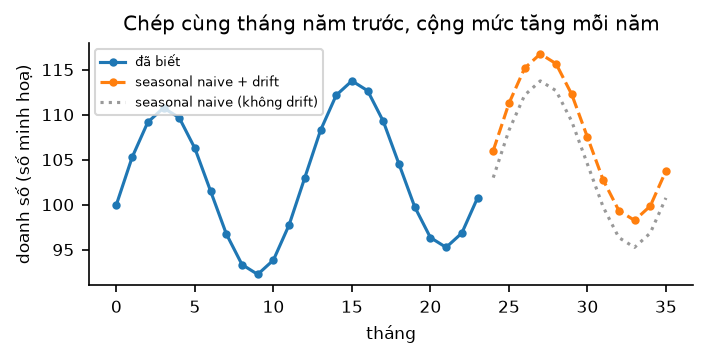

**Lý do.** Mô hình: **seasonal naive có drift trên thang log** — log tháng tới = log cùng tháng năm trước + drift. Từ 96 tháng
trước gốc, lấy sai phân mùa vụ của log: drift là trung bình, $\sigma^2$ là phương sai của chúng. Backtest gốc mỗi tháng 1/2012 →
12/2018, mỗi gốc 12 tháng (1.008 dự báo). Đo tổng dự báo / tổng thực − 1: âm là dự báo thấp hơn thực.

**Kết quả.**

In [11]:
def du_bao_log(y, goc, so_buoc=12, so_thang_hoc=96):
    hoc = y[(y.index < goc) & (y.index >= goc - pd.DateOffset(months=so_thang_hoc))]    # chỉ dữ liệu TRƯỚC gốc
    w = np.log(hoc)
    sp = (w - w.shift(12)).dropna()                                                      # sai phân mùa vụ
    drift, s2 = sp.mean(), sp.var(ddof=1)
    tg = pd.date_range(goc, periods=so_buoc, freq="MS")
    w_hat = np.array([w[t - pd.DateOffset(years=1)] + drift for t in tg])
    return pd.DataFrame({"trung_vi": np.exp(w_hat), "trung_binh": np.exp(w_hat) * (1 + s2 / 2), "s2": s2}, index=tg)


def backtest(y):
    bang = pd.concat([du_bao_log(y, g) for g in pd.date_range("2012-01-01", "2018-12-01", freq="MS")])
    bang["y"] = y.reindex(bang.index).to_numpy()
    return bang


g18 = du_bao_log(y, pd.Timestamp("2018-01-01")).iloc[0]
print(f"gốc 1/2018: σ² = {g18['s2']:.5f}, dự báo 1/2018 {g18['trung_vi']:,.0f} → {g18['trung_binh']:,.0f} triệu USD\n")

NGANH = {TONG: "Tổng bán lẻ + ăn uống", "Gasoline stations": "Trạm xăng", "Department stores": "Bách hoá",
         "Gift, novelty, and souvenir stores": "Quà tặng, lưu niệm"}
kq = {}
for ten, viet in NGANH.items():
    b = backtest(ban_le(ten))
    s2 = b["s2"].iloc[::12].mean()                              # σ² trung bình qua 84 gốc (mỗi gốc 12 dòng)
    kq[viet] = {"σ": np.sqrt(s2), "thẳng %": (b["trung_vi"].sum() / b["y"].sum() - 1) * 100,
                "hiệu chỉnh %": (b["trung_binh"].sum() / b["y"].sum() - 1) * 100, "σ²/2 %": s2 / 2 * 100}
print(pd.DataFrame(kq).T.round(3))

gốc 1/2018: σ² = 0.00041, dự báo 1/2018 433,240 → 433,330 triệu USD

                         σ  thẳng %  hiệu chỉnh %  σ²/2 %
Tổng bán lẻ + ăn uống 0.05    -0.47         -0.37    0.11
Trạm xăng             0.16     3.50          4.85    1.27
Bách hoá              0.07     9.69          9.93    0.26
Quà tặng, lưu niệm    0.08    -2.05         -1.77    0.29


Cột "hiệu chỉnh" trừ cột "thẳng" gần khớp $\sigma^2/2$ ở mọi dòng: lý thuyết đúng. Nhưng hiệu chỉnh chỉ giúp khi dự báo đang
**thấp** (tổng bán lẻ, quà tặng). Trạm xăng và bách hoá đã dự báo **cao** hơn thực, đẩy lên nữa làm tệ thêm; bách hoá lệch gần
+10% vì ngành đang suy giảm mà drift học từ quá khứ — lỗi mô hình, hiệu chỉnh không sửa được.

**Bài học.** Bật hiệu chỉnh khi cần **trung bình** (cộng dồn nhiều chuỗi, nhiều tháng; chấm bằng phạt bình phương) và $\sigma$ đủ
lớn (dữ liệu ngày, giờ, cửa hàng nhỏ). Không bật khi chấm bằng MAE: MAE nhỏ nhất ở trung vị, mà đổi ngược thẳng đã là trung vị.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Ngành khác.** Ba ngành, dữ liệu tới 2019: $\lambda$ Guerrero và $\sigma$ của sai phân mùa vụ log.

In [12]:
BA_NGANH = ["Fuel dealers", "Gasoline stations", "Jewelry stores"]
for ten in BA_NGANH:
    s = ban_le(ten)[:"2019-12"].dropna()
    sig = (np.log(s) - np.log(s).shift(12)).dropna().std(ddof=1)
    print(f"{ten:<20} λ Guerrero {guerrero(s, 12):+.3f} | σ = {sig:.3f} | σ²/2 = {sig**2 / 2 * 100:.2f}%")

Fuel dealers         λ Guerrero -0.407 | σ = 0.170 | σ²/2 = 1.45%
Gasoline stations    λ Guerrero -0.489 | σ = 0.124 | σ²/2 = 0.77%
Jewelry stores       λ Guerrero +0.482 | σ = 0.076 | σ²/2 = 0.29%


Chỉ ngành bán nhiên liệu sưởi (Fuel dealers) có $\sigma^2/2$ trên 1% (1,45%); trạm xăng 0,77%, trang sức 0,29%. Hai ngành
nhiên liệu còn có $\lambda$ **âm**: dao động tăng nhanh hơn cả mức (giá dầu lên xuống), nên phải ép mạnh hơn cả log. Một $\lambda$
cho mọi ngành là không đủ.

**Bài 2 — Ngày bán hàng.** Chia cho số ngày không phải Chủ nhật, tháng 2 so tháng 1/2023:

In [13]:
print(f"T2/T1: thẳng {(bang.loc['T2', 'tổng'] / bang.loc['T1', 'tổng'] - 1) * 100:+.1f}% | "
      f"chia ngày lịch {(bang.loc['T2', 'mỗi ngày'] / bang.loc['T1', 'mỗi ngày'] - 1) * 100:+.1f}% | "
      f"chia ngày không CN ({bang.loc['T1', 'ngày không CN']} → {bang.loc['T2', 'ngày không CN']}) "
      f"{(bang.loc['T2', 'mỗi ngày không CN'] / bang.loc['T1', 'mỗi ngày không CN'] - 1) * 100:+.1f}%")

T2/T1: thẳng -3.4% | chia ngày lịch +7.0% | chia ngày không CN (26 → 24) +4.7%


Kết luận không đổi — tháng 2 vẫn **tăng** — nhưng mức tăng nhỏ lại, vì tháng 1/2023 có 5 Chủ nhật còn tháng 2 có 4.

**Bài 3 — Tổng các trung vị.** Dự báo từng ngành rồi cộng lại, so với tổng thực:

In [14]:
phan = [backtest(ban_le(ten)) for ten in BA_NGANH]
tong = sum(p[["trung_vi", "trung_binh", "y"]] for p in phan)
for ten, p in zip(BA_NGANH + ["TỔNG ba ngành"], phan + [tong], strict=True):
    print(f"{ten:<20} thẳng {(p['trung_vi'].sum() / p['y'].sum() - 1) * 100:+6.2f}% | "
          f"hiệu chỉnh {(p['trung_binh'].sum() / p['y'].sum() - 1) * 100:+6.2f}%")

Fuel dealers         thẳng  -0.09% | hiệu chỉnh  +1.60%
Gasoline stations    thẳng  +3.50% | hiệu chỉnh  +4.85%
Jewelry stores       thẳng  +0.23% | hiệu chỉnh  +0.61%
TỔNG ba ngành        thẳng  +3.11% | hiệu chỉnh  +4.43%


Tổng ba ngành bị trạm xăng — ngành lớn nhất — chi phối: đã dự báo cao 3,11%, hiệu chỉnh đẩy lên 4,43%. Hiệu chỉnh ở tổng
không giúp hơn ở một ngành: phần đẩy lên của tổng chỉ là trung bình có trọng số của phần đẩy từng ngành. Sai lệch do đổi ngược
cùng một chiều nên **không bù trừ** khi cộng; điều quyết định vẫn là lỗi mô hình của ngành lớn.

## Tự kiểm

- [ ] Giải thích vì sao tháng 2/2023 "giảm" theo tổng mà "tăng" theo ngày.
- [ ] Đổi 150 tỷ lúc CPI 125 về giá năm gốc (CPI 100), rồi ra mức mỗi người.
- [ ] Nói được khi nào log vừa khít, khi nào ép quá tay.
- [ ] Chọn $\lambda$ Guerrero cho ba năm $\mu$ = 100, 400, 900, $s$ = 5, 20, 45.
- [ ] Giải thích vì sao $\exp$(dự báo log) là trung vị, và khi nào cần nhân $1 + \sigma^2/2$.